In [9]:
from brian2 import *
sys.path.append('Neuron and Synapse Models')
from neuronModels import *
from ringAttractorTEMP import *

sys.path.append('Tools')
from plottingTools import *

In [10]:
# Simulation parameters
defaultclock.dt = 0.1*ms

In [11]:
# Setting network parameters
num_neurons = 120
tau=10*ms
sigma_noise=1*mV
V_rest=-70*mV

In [12]:
# External input: a spatially modulated current.

# For example, we define a Gaussian input centered at a particular position (stimulus_center)
stimulus_center = 0  # center of the bump on the ring
stimulus_width = 0.5  # width in radians
I0 = 30*mV         # amplitude of the external input

# Define the external input as a function of neuron position
positions = linspace(0, 2*pi, num_neurons, endpoint=False)
# I_ext_array = I0 * exp(-((positions - stimulus_center)**2) / (2 * stimulus_width**2))
d = np.angle(np.exp(1j * (positions - stimulus_center)))
I_ext_array = I0 * np.exp(-(d**2) / (2 * stimulus_width**2))

In [13]:
# Creating the equation object
neuron_eq = Equations(LIF_xi_eq, tau=tau, V_rest=V_rest, sigma_noise=sigma_noise)

In [14]:
# Create neuron group
Vth=-48*mV
V_reset=-80*mV
refractory_period=5*ms

# Connectivity parameters - Mexican hat
sigma_exc = 0.0875
sigma_inh = 0.25
g_exc = 1.0*mV
g_inh = -0.475*mV

# Connectivity parameters - Cosine
g_cosine = 0.1*mV
            
ringAttractor = RingAttractor(neuron_eq, 
                 num_neurons, 
                 Vth, V_reset, refractory_period,
                 # Choose connectivity profile: 'mexican_hat', 'gaussian', or 'cosine'
                 syn_profile='cosine',
                 autapse=True,
                 g_cosine = g_cosine, # Cosine connectivity parameter
                 sigma_exc=sigma_exc, sigma_inh=sigma_inh, g_exc=g_exc, g_inh=g_inh) # Connectivity parameters - Mexican hat

ringAttractor.ring_pool.I_ext = I_ext_array

# Network Operations:
# Clipping - Reverse Potential Behaviour
# Define a network operation to enforce the lower bound
@network_operation(dt=defaultclock.dt)
def enforce_lower_bound():
    # Using the built-in clip function (from numpy)
    ringAttractor.ring_pool.V[:] = clip(ringAttractor.ring_pool.V[:], V_reset, inf*volt)
    

In [15]:
# Setup monitors: spike monitor and state monitor for membrane potential and external input
spikemon = SpikeMonitor(ringAttractor.ring_pool)
statemon = StateMonitor(ringAttractor.ring_pool, 'V', record=True)
inputmon = StateMonitor(ringAttractor.ring_pool, 'I_ext', record=True)  # if you want to check the input

net = Network(ringAttractor.BrianObjects + [enforce_lower_bound, spikemon, statemon, inputmon])

input_on = 0.5*second
input_off = 3*second
sim_duration=input_on+input_off

# Run simulation
net.run(sim_duration)
# Turn off input for the second half
ringAttractor.ring_pool.I_ext = I_ext_array * 0
net.run(input_off)

WARNING    /home/bmaacaron-iit.local/Documents/Git Repos/JointAttractorNets/Tools/plottingTools.py:342: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
 [py.warnings]


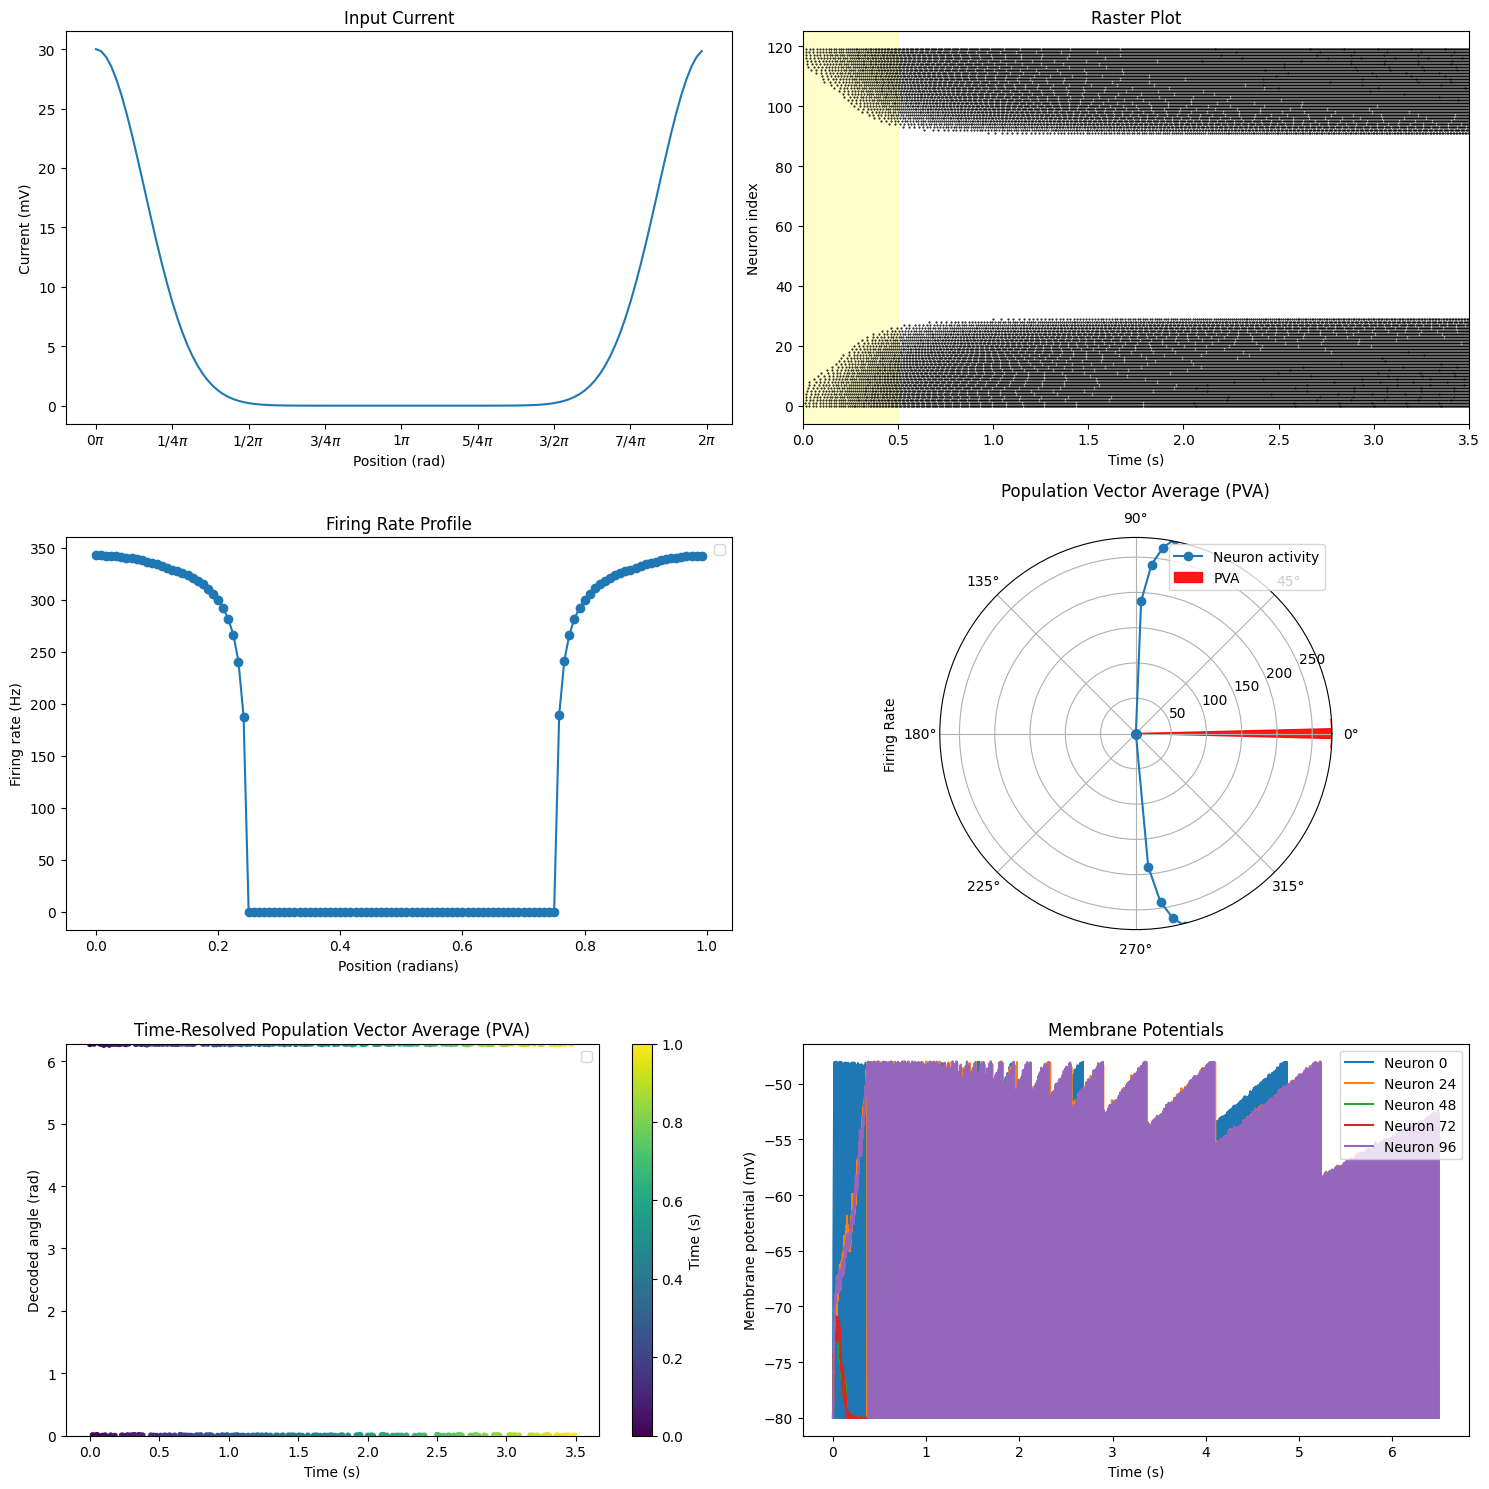

In [ ]:
from matplotlib.ticker import FuncFormatter
from sympy import Rational

#+---------------------------------------------------------------------------+
#|                           Plotting the Results                            |
#+---------------------------------------------------------------------------+

# Create a figure with 6 subplots arranged in 3 rows and 2 columns
fig = plt.figure(figsize=(15, 15))

# 1. Input Current Plot
ax1 = fig.add_subplot(3, 2, 1)
ax1.plot(positions/pi, I_ext_array/mV)
# Define the formatter function
def pi_formatter(x, pos):
    # Convert the value to a fraction of pi
    frac = Rational(x).limit_denominator(10)  # Limit denominator to avoid too large fractions
    if frac == 0:
        return r"$0$"
    elif frac == 2:
        return r"$2\pi$"
    else:
        return r"${}\pi$".format(frac)

# Set the custom formatter for the x-axis
ax1.xaxis.set_major_formatter(FuncFormatter(pi_formatter))
ax1.set_title('Input Current')
ax1.set_xlabel('Position (rad)')
ax1.set_ylabel('Current (mV)')

# 2. Raster Plot
ax2 = fig.add_subplot(3, 2, 2)
raster_plot(spikemon, ax=ax2, stim_periods=(0*second, input_on),
            stim_display_method='highlight', duration=sim_duration)

# 3. Firing Rate Profile Plot
ax3 = fig.add_subplot(3, 2, 3)
firing_rate, _ = firing_rate_profile(spikemon, positions/(2*pi), sim_duration, ax=ax3)

# 4. Polar Plot of the Population Vector Average (PVA)
ax4 = fig.add_subplot(3, 2, 4, projection='polar')
polar_plot_PVA(firing_rate, positions, scale=1.2, ax=ax4)

# 5. Time-Resolved PVA Plot
ax5 = fig.add_subplot(3, 2, 5)
_, _ = time_resolved_PVA(spikemon, positions, sim_duration, num_neurons, ax=ax5, color_windows=True)

# 6. Membrane potential traces
ax6 = fig.add_subplot(3, 2, 6)
membrane_potential_traces(statemon, sim_duration, ax=ax6)

plt.tight_layout()
plt.show()